<a href="https://colab.research.google.com/github/MaryamManzoor31/FET-Lab-Codes/blob/main/9_geometry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving geometry.png to geometry (5).png
[[255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 ...
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]]
Squares: 3
Rectangles: 2
Circles: 4


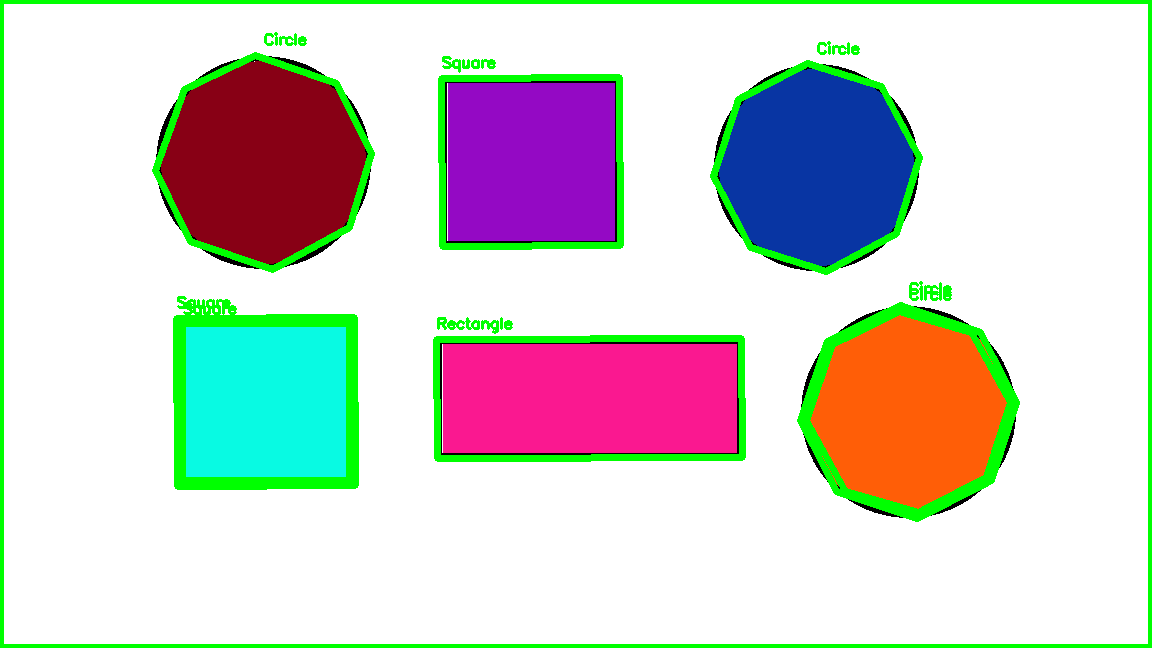

In [7]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
from google.colab import files

# Upload and read image
uploaded = files.upload()
img = cv2.imread('geometry.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Threshold to make image black & white
_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# Find contours - changed RETR_EXTERNAL to RETR_LIST to find all contours
print(thresh)
contours, _ = cv2.findContours(thresh, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

circles = squares = rectangles = 0

for cnt in contours:
    # Approximate the shape
    epsilon = 0.04 * cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, epsilon, True)

    shape_name = "Unknown" # Initialize shape_name
    px, py = 0, 0 # Initialize variables for text placement (p_x, p_y)

    # If the shape has 4 vertices, it's a quadrilateral
    if len(approx) == 4:
        px, py, w, h = cv2.boundingRect(approx) # Use px, py for consistency with drawing text
        aspect_ratio = float(w) / h

        # A square will have an aspect ratio very close to 1
        if 0.9 <= aspect_ratio <= 1.1: # Widened range for squares
            squares += 1
            shape_name = "Square"
        else:
            rectangles += 1
            shape_name = "Rectangle"

    # For shapes with more vertices, check if they are circular
    elif len(approx) >= 8: # Changed to >= 8 to include shapes approximated with 8 vertices
        # Get bounding rectangle for aspect ratio check
        px, py, w, h = cv2.boundingRect(approx)
        aspect_ratio = float(w) / h

        # Check if the aspect ratio of the bounding box is close to 1
        if 0.9 <= aspect_ratio <= 1.1: # A slightly more lenient range for circles
            circles += 1
            shape_name = "Circle"
            # For circles, get the center and radius for text placement
            (cx, cy), radius = cv2.minEnclosingCircle(cnt)
            px, py = int(cx), int(cy) # Use center for text x, y
            py = py - int(radius) # Adjust y to be above the circle

    # Draw the name and contours if a shape was identified
    if shape_name != "Unknown":
        cv2.putText(img, shape_name, (px, py - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
        cv2.drawContours(img, [approx], 0, (0, 255, 0), 5)

print(f"Squares: {squares}")
print(f"Rectangles: {rectangles}")
print(f"Circles: {circles}")
cv2_imshow(img)